In [1]:
%pip install -q "tf-keras==2.19.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 45.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have tensorflow 2.19.1 which is incompatible.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow 2.19.1 which is incompatible.


In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf
import tf_keras

print("TensorFlow:", tf.__version__)
print("Legacy Keras:", tf_keras.__version__)

TensorFlow: 2.19.1
Legacy Keras: 2.19.0


In [2]:
%pip install -q biopython

from google.colab import drive
drive.mount("/content/drive")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 30.0 MB/s eta 0:00:00
Mounted at /content/drive


In [3]:
from pathlib import Path
import subprocess
import os

REPO = Path("/content/MMUbiPred")
COMMIT = "fb45202d0a91c58e74d73a9f8e4ad43dff4e48e5"

if not (REPO / ".git").exists():
    subprocess.run(
        [
            "git",
            "clone",
            "https://github.com/PakhrinLab/MMUbiPred.git",
            str(REPO),
        ],
        check=True,
    )

subprocess.run(
    ["git", "-C", str(REPO), "checkout", COMMIT],
    check=True,
)

os.chdir(REPO)

print("Working directory:", Path.cwd())

Working directory: /content/MMUbiPred


In [4]:
from pathlib import Path
import shutil

DRIVE_MODEL = Path(
    "/content/drive/MyDrive/MMUbiPred-replication/artifacts/"
    "DeepUBI_AAindex_One_Hot_Emb_drop_out2423.h5"
)

LOCAL_MODEL = Path(
    "/content/MMUbiPred/"
    "DeepUBI_AAindex_One_Hot_Emb_drop_out2423.h5"
)

assert DRIVE_MODEL.exists(), f"Model not found: {DRIVE_MODEL}"
assert DRIVE_MODEL.stat().st_size == 36_608_352, (
    f"Unexpected model size: {DRIVE_MODEL.stat().st_size} bytes"
)

shutil.copy2(DRIVE_MODEL, LOCAL_MODEL)

print("Model copied successfully")
print("Location:", LOCAL_MODEL)
print("Size:", LOCAL_MODEL.stat().st_size, "bytes")

Model copied successfully
Location: /content/MMUbiPred/DeepUBI_AAindex_One_Hot_Emb_drop_out2423.h5
Size: 36608352 bytes


In [5]:
import os
from Bio import SeqIO
import numpy as np
import pandas as pd
os.chdir("/content/MMUbiPred")
# Independent Testing
indep_test_x_81 = []
indep_test_y_81 = []
posit_1 = 1;
negat_0 = 0;

aminoacids='ARNDCQEGHILKMFPSTWYV-'

def binary_encode(Sequence_one_hot_encoding):
    aa2v={x:y for x,y in zip(aminoacids,np.eye(21,21).tolist())}
    aa2v['X']=np.zeros(21)
    encoding=[]
    for i in range(len(Sequence_one_hot_encoding)):
        s=Sequence_one_hot_encoding[i]
        encoding.append([aa2v[x] for x in s])
    encoding=np.array(encoding)
    return encoding

aaindex=pd.read_table('aaindex31.txt',sep='\s+',header=None)
aaindex=aaindex.subtract(aaindex.min(axis=1),axis=0).divide((aaindex.max(axis=1)-aaindex.min(axis=1)),axis=0)
aa=[x for x in 'ARNDCQEGHILKMFPSTWYV']
aaindex=aaindex.to_numpy().T
index={x:y for x,y in zip(aa,aaindex.tolist())}
index['-']=np.zeros(31).tolist()
index['X']=np.zeros(31).tolist()

def index_encode(Sequence_one_hot_encoding):
    encoding=[]
    for i in range(len(Sequence_one_hot_encoding)):
        s=Sequence_one_hot_encoding[i]
        encoding.append([index[x] for x in (s)])
    encoding=np.array(encoding)
    return encoding

alphabet = 'ARNDCQEGHILKMFPSTWYV-'


char_to_int = dict((c, i) for i, c in enumerate(alphabet))
int_to_char = dict((i, c) for i, c in enumerate(alphabet))

def inner1():
    #Input
    data = seq_record.seq

    for char in data:
        if char not in alphabet:
            return
    integer_encoded = [char_to_int[char] for char in data]
    indep_test_x_81.append(integer_encoded)
    indep_test_y_81.append(posit_1)
for seq_record in SeqIO.parse("Positive_10_percent_independent_test_set_DeepUBI.fasta", "fasta"):
    inner1()

def inner2():
    #Input
    data = seq_record.seq

    for char in data:
        if char not in alphabet:
            return
    integer_encoded = [char_to_int[char] for char in data]
    indep_test_x_81.append(integer_encoded)
    indep_test_y_81.append(negat_0)
for seq_record in SeqIO.parse("Negative_10_percent_independent_test_set_DeepUBI.fasta", "fasta"):
    inner2()

# Changing to array (matrix)
indep_test_x_81 = np.array(indep_test_x_81)
indep_test_y_81 = np.array(indep_test_y_81)

print(indep_test_x_81.shape,indep_test_y_81.shape)

AAindex_Test_AAAAA_81_Sequence = []
for i in range(len(indep_test_x_81)):
    integer_of_string = str(indep_test_x_81[i])
    integer_of_string = integer_of_string.strip("[").strip("]").strip(" ")
    keras_job = integer_of_string.split()
    individual_AA_peptide = []
    for i in range(len(keras_job)):
        index_value = int(keras_job[i])
        individual_AA_peptide.append(int_to_char.get(index_value))
    individual_AA_peptide = "".join(individual_AA_peptide)
    AAindex_Test_AAAAA_81_Sequence.append(individual_AA_peptide)

yval = indep_test_y_81

x_ind_49 = indep_test_x_81[:,[i for i in range(16,65)]]

AAindex_indi_AA_Sequence = []
for i in range(len(x_ind_49)):
    integer_of_string = str(x_ind_49[i])
    integer_of_string = integer_of_string.strip("[").strip("]").strip(" ")
    keras_job = integer_of_string.split()
    individual_AA_peptide = []
    for i in range(len(keras_job)):
        index_value = int(keras_job[i])
        individual_AA_peptide.append(int_to_char.get(index_value))
    individual_AA_peptide = "".join(individual_AA_peptide)
    AAindex_indi_AA_Sequence.append(individual_AA_peptide)

binaryCoding_Independent_Test = binary_encode(AAindex_indi_AA_Sequence)

AAindexCoding_Independent_Test = index_encode(AAindex_indi_AA_Sequence)

<>:24: SyntaxWarning: invalid escape sequence '\s'
<>:24: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_5510/3287258175.py:24: SyntaxWarning: invalid escape sequence '\s'
  aaindex=pd.read_table('aaindex31.txt',sep='\s+',header=None)


(12598, 81) (12598,)


In [6]:
binaryCoding_Independent_Test.shape

(12598, 49, 21)

In [7]:
AAindexCoding_Independent_Test.shape

(12598, 49, 31)

In [8]:
x_ind_49.shape

(12598, 49)

# Load the model

In [9]:
from tensorflow import keras
model = keras.models.load_model(
    "DeepUBI_AAindex_One_Hot_Emb_drop_out2423.h5",
    compile=False,
)
Y_pred = model.predict([AAindexCoding_Independent_Test,binaryCoding_Independent_Test,x_ind_49])

394/394 [==============================] - 10s 25ms/step


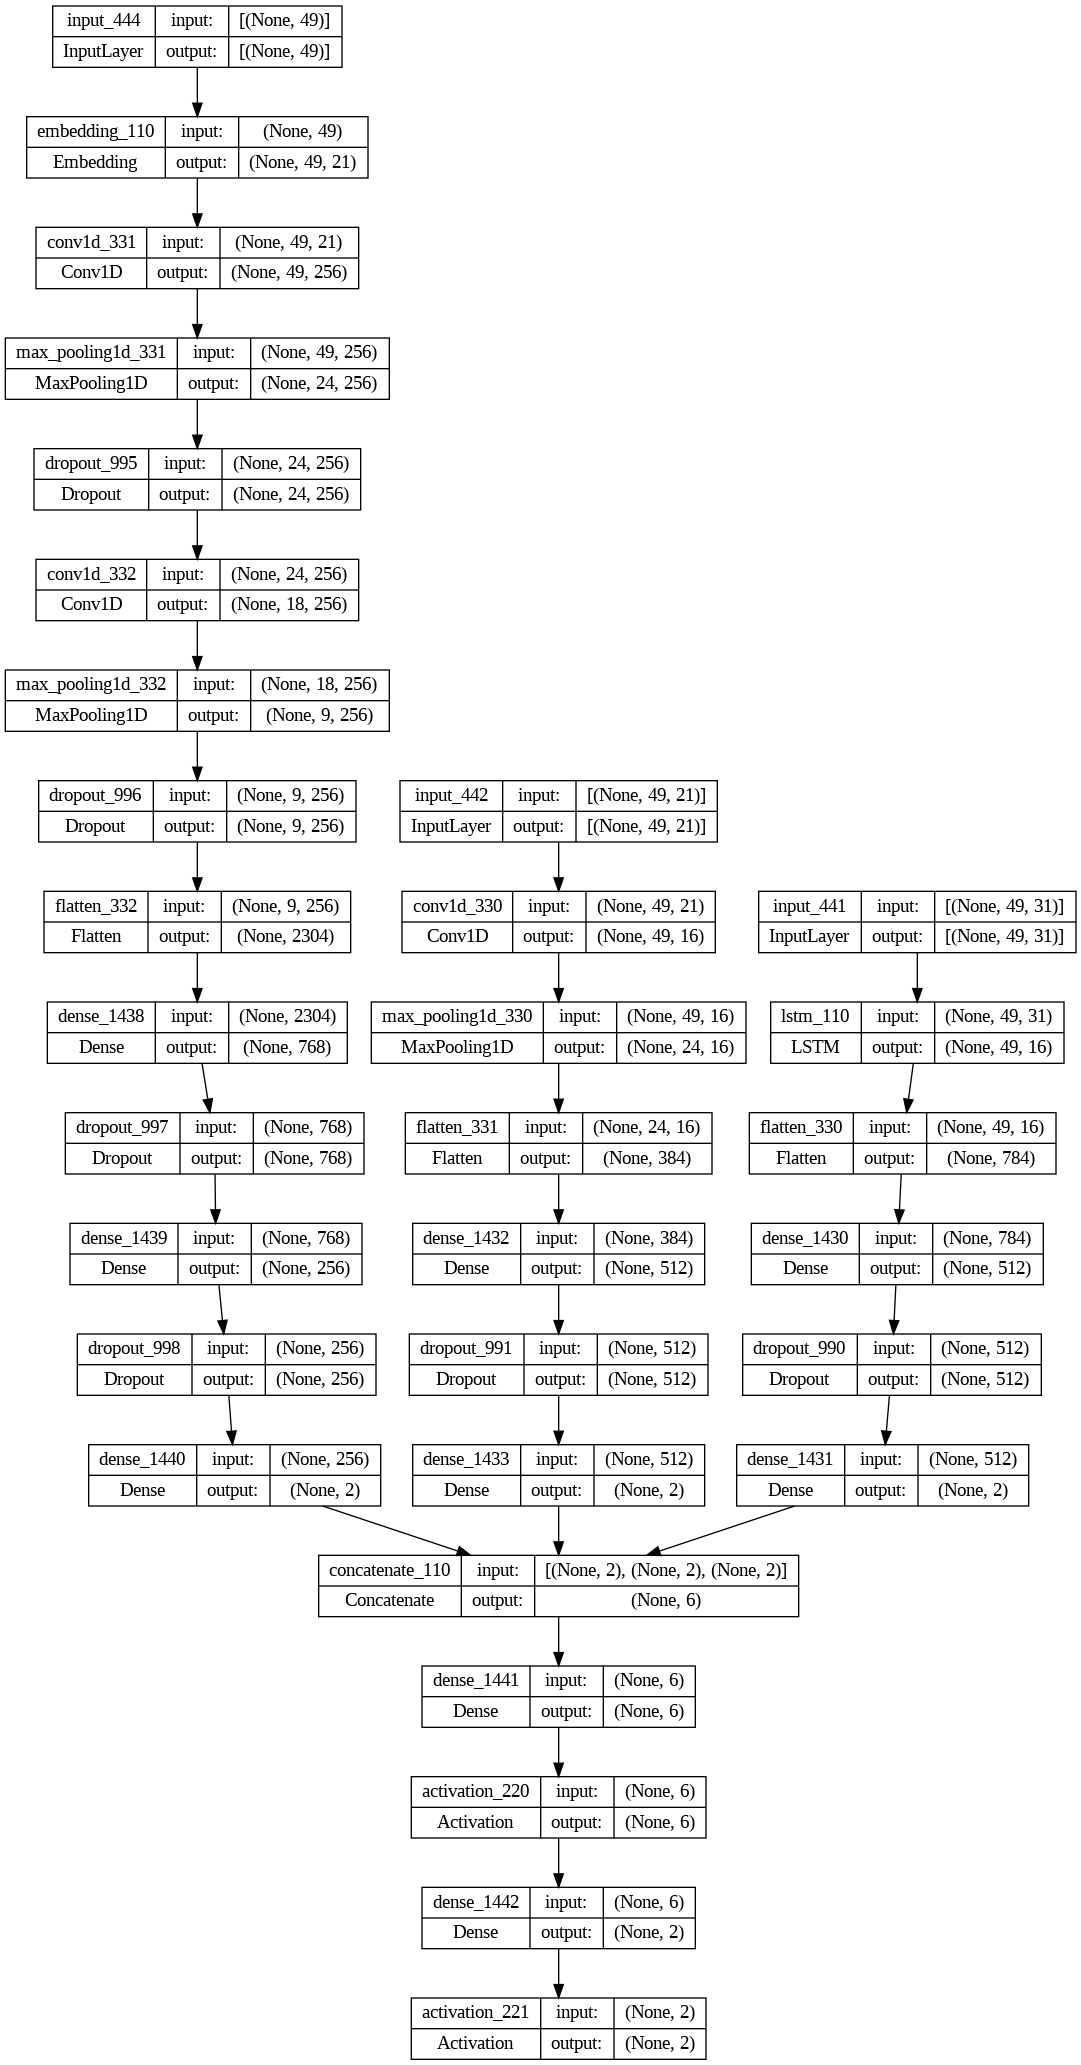

In [10]:
from tensorflow.keras.utils import plot_model
plot_model(model,show_shapes = True, to_file='Large_Ubiquitination.png')

In [11]:
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import confusion_matrix
Y_pred = model.predict([AAindexCoding_Independent_Test,binaryCoding_Independent_Test,x_ind_49])

t_pred2 = Y_pred[:,1]

Y_pred = (Y_pred > 0.5)
y_pred1 = [np.argmax(y, axis=None, out=None) for y in Y_pred]
y_pred1 = np.array(y_pred1)


mcc_test = matthews_corrcoef(yval, y_pred1)
# For sensitivity and specificity
sp_1, sn_1 = confusion_matrix(yval, y_pred1)
sp_2_test = sp_1[0]/(sp_1[0]+sp_1[1])
sn_2_test = sn_1[1]/(sn_1[0]+sn_1[1])
# ROC


print("Specificity = ",sp_2_test, " Sensitivity = ",sn_2_test)
print(model.summary())
print("testx",yval.shape)

y_pred = y_pred1



394/394 [==============================] - 10s 26ms/step
Specificity =  0.8067729083665338  Sensitivity =  0.7498020585906572
Model: "functional_221"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_444 (InputLayer)      [(None, 49)]                 0         []                            
                                                                                                  
 embedding_110 (Embedding)   (None, 49, 21)               483       ['input_444[0][0]']           
                                                                                                  
 conv1d_331 (Conv1D)         (None, 49, 256)              5632      ['embedding_110[0][0]']       
                                                                                                  
 max_pooling1d_331 (MaxPool  (None, 24, 256)              

In [12]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score,matthews_corrcoef
Accuracyyyyy = accuracy_score(yval, y_pred)
cm = confusion_matrix(yval, y_pred)
mcc = matthews_corrcoef(yval, y_pred)

print("Matthews Correlation : ",mcc)
print("\n")
print("Confusion Matrix : \n",cm)
print("\n")
print("Accuracy on test set:   ",Accuracyyyyy)
print("\n")

TP = cm[1][1]
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]

Sensitivity = TP/(TP+FN)

Specificity = TN/(TN+FP)


print("Sensitivity:   ",Sensitivity,"\t","Specificity:   ",Specificity)

print(classification_report(yval, y_pred))

Matthews Correlation :  0.5458386140298045


Confusion Matrix : 
 [[4050  970]
 [1896 5682]]


Accuracy on test set:    0.7725035719955549


Sensitivity:    0.7498020585906572 	 Specificity:    0.8067729083665338
              precision    recall  f1-score   support

           0       0.68      0.81      0.74      5020
           1       0.85      0.75      0.80      7578

    accuracy                           0.77     12598
   macro avg       0.77      0.78      0.77     12598
weighted avg       0.79      0.77      0.77     12598



# Thank You

In [13]:
import sys
import hashlib
from pathlib import Path
import tensorflow as tf
import tf_keras

print("Python:", sys.version)
print("TensorFlow:", tf.__version__)
print("Legacy Keras:", tf_keras.__version__)

files = [
    "DeepUBI_AAindex_One_Hot_Emb_drop_out2423.h5",
    "aaindex31.txt",
    "Positive_10_percent_independent_test_set_DeepUBI.fasta",
    "Negative_10_percent_independent_test_set_DeepUBI.fasta",
]

for filename in files:
    path = Path("/content/MMUbiPred") / filename
    digest = hashlib.sha256(path.read_bytes()).hexdigest()
    print(f"{filename}: {path.stat().st_size} bytes, SHA256={digest}")

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
TensorFlow: 2.19.1
Legacy Keras: 2.19.0
DeepUBI_AAindex_One_Hot_Emb_drop_out2423.h5: 36608352 bytes, SHA256=a9393c05635f8019d08fe916885bdf3f31225859b2d0cb4130ec4c2bd89a5001
aaindex31.txt: 3357 bytes, SHA256=26ddb1bff5bcca51d1e1fb0d77b76da01564e6269bd9cac62774e36ac673524d
Positive_10_percent_independent_test_set_DeepUBI.fasta: 726805 bytes, SHA256=c6a5107096fa0a60581a7e81e622ef1b865cf9b5db6823f81d6275e273f1359d
Negative_10_percent_independent_test_set_DeepUBI.fasta: 481693 bytes, SHA256=659dad50721cacce097b174c41c05517ca064faf54defa21f8722649ce2ab2da
